# Telco Customer Churn Prediction using Machine Learning and Deep Learning

In [32]:
# IMPORT LIBRARIES
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
save_dir = "plots/visuals"
# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

In [33]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)



In [34]:

import xgboost as xgb


In [35]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [36]:
# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.neural_network import MLPClassifier

In [37]:
# LOAD DATASET
dataset = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(dataset)

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [38]:

# DATA PREPROCESSING
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Encode target column
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop customerID
df.drop('customerID', axis=1, inplace=True)

# One-hot encoding
cat_cols = df.select_dtypes(include='object').columns.tolist()

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Scale numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (5634, 30)
Testing Shape: (1409, 30)


In [49]:

# FUNCTION FOR EVALUATION
def evaluate_model(model, X_test, y_test, y_pred, y_prob):

    print("\\nAccuracy Score:")
    print(accuracy_score(y_test, y_pred))

    print("\\nROC-AUC Score:")
    print(roc_auc_score(y_test, y_prob))

    print("\\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(type(model).__name__)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


\n==============================
LOGISTIC REGRESSION
\nAccuracy Score:
0.8048261178140526
\nROC-AUC Score:
0.8419954015861943
\nClassification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



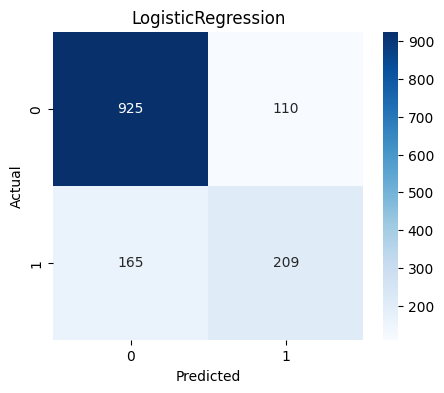

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
# MACHINE LEARNING MODEL 1 - LOGISTIC REGRESSION
print("\\n==============================")
print("LOGISTIC REGRESSION")
print("==============================")

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:,1]

evaluate_model(
    lr_model,
    X_test,
    y_test,
    y_pred_lr,
    y_prob_lr
)
plt.show()
plt.savefig(os.path.join(save_dir, "Logistic Regression.png"))


\n==============================
RANDOM FOREST
\nAccuracy Score:
0.8055358410220014
\nROC-AUC Score:
0.8432677155183549
\nClassification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



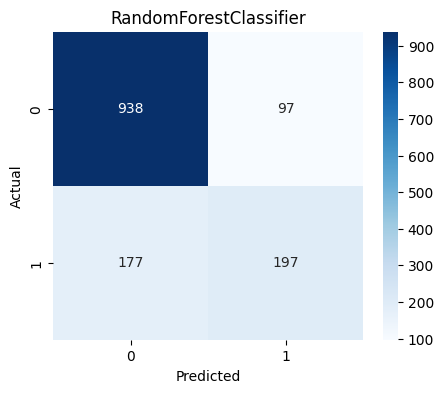

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [44]:
# MACHINE LEARNING MODEL 2 - RANDOM FOREST
print("\\n==============================")
print("RANDOM FOREST")
print("==============================")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

evaluate_model(
    rf_model,
    X_test,
    y_test,
    y_pred_rf,
    y_prob_rf
)
plt.show()
plt.savefig(os.path.join(save_dir, "Random Forest.png"))

\n==============================
XGBOOST
\nAccuracy Score:
0.7927608232789212
\nROC-AUC Score:
0.8373272365599731
\nClassification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.63      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



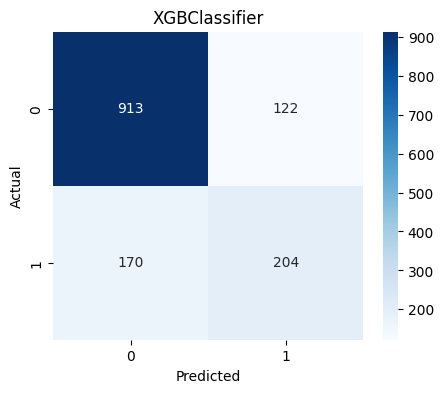

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [45]:
# MACHINE LEARNING MODEL 3 - XGBOOST
print("\\n==============================")
print("XGBOOST")
print("==============================")

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    learning_rate=0.05,
    max_depth=6,
    n_estimators=200,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

evaluate_model(
    xgb_model,
    X_test,
    y_test,
    y_pred_xgb,
    y_prob_xgb
)
plt.show()
plt.savefig(os.path.join(save_dir, "XGBClassifier.png"))

\n==============================
DEEP LEARNING - ANN


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7362 - loss: 0.5114 - val_accuracy: 0.7924 - val_loss: 0.4544
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7903 - loss: 0.4409 - val_accuracy: 0.7808 - val_loss: 0.4453
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7937 - loss: 0.4396 - val_accuracy: 0.7799 - val_loss: 0.4391
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8023 - loss: 0.4261 - val_accuracy: 0.7817 - val_loss: 0.4395
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7996 - loss: 0.4279 - val_accuracy: 0.7906 - val_loss: 0.4365
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7959 - loss: 0.4279 - val_accuracy: 0.7879 - val_loss: 0.4357
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8043 - loss: 0.4195 - val_accuracy: 0.7782 - val_loss: 0.4397
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8065 - loss: 0.4206 - val_accuracy: 0.

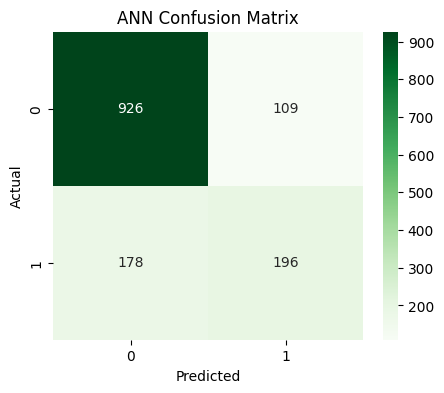

<Figure size 640x480 with 0 Axes>

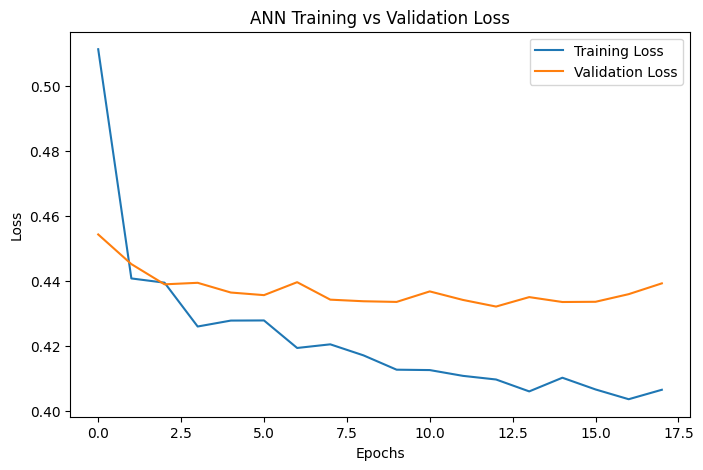

\n==============================
MODEL COMPARISON
                 Model  ROC-AUC Score
0  Logistic Regression       0.841995
1        Random Forest       0.843268
2              XGBoost       0.837327
3    ANN Deep Learning       0.841288


<Figure size 640x480 with 0 Axes>

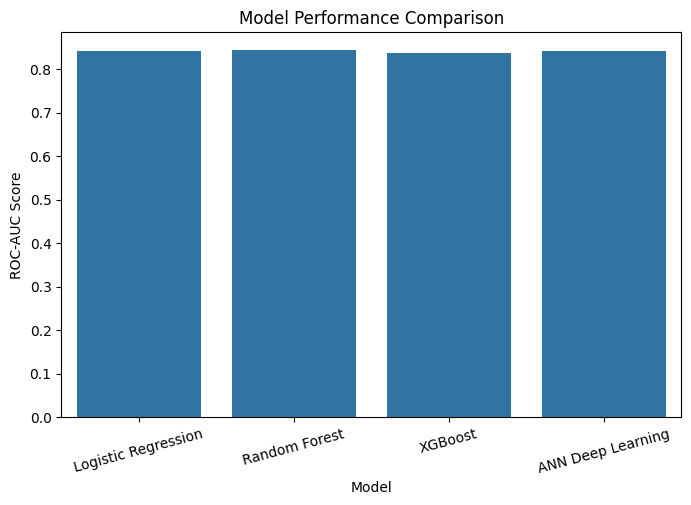

<Figure size 640x480 with 0 Axes>

In [46]:
# DEEP LEARNING MODEL - ARTIFICIAL NEURAL NETWORK
print("\\n==============================")
print("DEEP LEARNING - ANN")
print("==============================")

ann_model = Sequential()

# Input Layer + Hidden Layer 1
ann_model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
ann_model.add(Dropout(0.3))

# Hidden Layer 2
ann_model.add(Dense(32, activation='relu'))
ann_model.add(Dropout(0.3))

# Hidden Layer 3
ann_model.add(Dense(16, activation='relu'))

# Output Layer
ann_model.add(Dense(1, activation='sigmoid'))

# Compile Model
ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train Model
history = ann_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Predictions
y_prob_ann = ann_model.predict(X_test)
y_prob_ann = y_prob_ann.flatten()

y_pred_ann = (y_prob_ann > 0.5).astype(int)

# Evaluation
print("\\nAccuracy Score:")
print(accuracy_score(y_test, y_pred_ann))

print("\\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_ann))

print("\\nClassification Report:")
print(classification_report(y_test, y_pred_ann))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
plt.savefig(os.path.join(save_dir, "Ann Confusion Matrix.png"))

# TRAINING vs VALIDATION LOSS GRAPH
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("ANN Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()
plt.savefig(os.path.join(save_dir, "ANN Training vs Validation Loss.png"))


# ====================================================
# MODEL COMPARISON
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost',
        'ANN Deep Learning'
    ],

    'ROC-AUC Score': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_ann)
    ]
})

print("\\n==============================")
print("MODEL COMPARISON")
print("==============================")

print(results)

# Plot comparison
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='ROC-AUC Score',
    data=results
)

plt.title("Model Performance Comparison")
plt.xticks(rotation=15)
plt.show()
plt.savefig(os.path.join(save_dir, "Model Performance Comparison.png"))